In [3]:
import pandas as pd
import numpy as np

file_path = '/content/delivery_data.csv'
df = pd.read_csv(file_path)

In [4]:
trip_df = pd.read_csv('/content/trip_corridor_cleaned.csv')

In [5]:
corridor_summary = (
    trip_df
    .groupby(["source_center", "destination_center"])
    .agg(
        trips=("trip_uuid", "count"),
        median_actual_time=("actual_time", "median"),
        mean_actual_time=("actual_time", "mean"),
        median_osrm_time=("osrm_time", "median"),
        mean_osrm_time=("osrm_time", "mean"),
        median_distance=("actual_distance_to_destination", "median"),
        median_osrm_distance=("osrm_distance", "median"),
        median_delay_ratio=("delay_ratio", "median"),
        mean_delay_ratio=("delay_ratio", "mean"),
        delay_rate=("is_delayed", "mean"),
        delayed_trips=("is_delayed", "sum")
    )
    .reset_index()
)

corridor_summary["corridor"] = (
    corridor_summary["source_center"].astype(str)
    + " -> "
    + corridor_summary["destination_center"].astype(str)
)

print("Corridor summary shape:", corridor_summary.shape)
display(corridor_summary.head())

Corridor summary shape: (2783, 14)


,source_center,destination_center,trips,median_actual_time,mean_actual_time,median_osrm_time,mean_osrm_time,median_distance,median_osrm_distance,median_delay_ratio,mean_delay_ratio,delay_rate,delayed_trips,corridor
0,IND000000AAL,IND411033AAA,18,74.5,87.833333,27.0,27.611111,15.820098,24.50055,2.695000,3.128867,1.0,18,IND000000AAL -> IND411033AAA
1,IND000000AAQ,IND700028AAB,2,85.0,85.000000,14.0,14.000000,11.319068,13.90065,6.071429,6.071429,1.0,2,IND000000AAQ -> IND700028AAB
2,IND000000AAS,IND783370AAC,9,53.0,61.333333,30.0,29.333333,28.591783,41.78220,1.766667,2.090123,1.0,9,IND000000AAS -> IND783370AAC
3,IND000000AAZ,IND444203AAA,1,289.0,289.000000,48.0,48.000000,59.853801,67.49820,6.020833,6.020833,1.0,1,IND000000AAZ -> IND444203AAA
4,IND000000AAZ,IND444303AAA,1,160.0,160.000000,40.0,40.000000,44.986725,53.73220,4.000000,4.000000,1.0,1,IND000000AAZ -> IND444303AAA


In [6]:
import networkx as nx

G = nx.DiGraph()

for _, row in corridor_summary.iterrows():
    source = row["source_center"]
    destination = row["destination_center"]

    G.add_edge(
        source,
        destination,
        trips=row["trips"],
        median_actual_time=row["median_actual_time"],
        median_osrm_time=row["median_osrm_time"],
        median_distance=row["median_distance"],
        median_delay_ratio=row["median_delay_ratio"],
        mean_delay_ratio=row["mean_delay_ratio"],
        delay_rate=row["delay_rate"],
        delayed_trips=row["delayed_trips"]
    )

print("Number of nodes:", G.number_of_nodes())
print("Number of edges:", G.number_of_edges())

Number of nodes: 1657
Number of edges: 2783


In [7]:
print("Is graph directed?", G.is_directed())
print("Number of nodes:", G.number_of_nodes())
print("Number of edges:", G.number_of_edges())

density = nx.density(G)
print("Graph density:", density)

isolated_nodes = list(nx.isolates(G))
print("Number of isolated nodes:", len(isolated_nodes))

Is graph directed? True
Number of nodes: 1657
Number of edges: 2783
Graph density: 0.0010142157848856703
Number of isolated nodes: 0


In [8]:
print("Is graph directed?", G.is_directed())
print("Number of nodes:", G.number_of_nodes())
print("Number of edges:", G.number_of_edges())

density = nx.density(G)
print("Graph density:", density)

isolated_nodes = list(nx.isolates(G))
print("Number of isolated nodes:", len(isolated_nodes))

Is graph directed? True
Number of nodes: 1657
Number of edges: 2783
Graph density: 0.0010142157848856703
Number of isolated nodes: 0


In [10]:
node_features = pd.DataFrame({
    "center": list(G.nodes())
})

node_features["in_degree"] = node_features["center"].map(dict(G.in_degree()))
node_features["out_degree"] = node_features["center"].map(dict(G.out_degree()))
node_features["total_degree"] = node_features["in_degree"] + node_features["out_degree"]

print("Node features shape:", node_features.shape)
display(node_features.sort_values("total_degree", ascending=False).head(10))

Node features shape: (1657, 4)


,center,in_degree,out_degree,total_degree
25,IND000000ACB,45,49,94
12,IND562132AAA,36,35,71
24,IND160002AAC,32,29,61
61,IND421302AAG,29,29,58
64,IND501359AAE,30,27,57
67,IND712311AAA,24,22,46
102,IND110037AAM,21,24,45
1,IND411033AAA,23,20,43
47,IND131028AAB,20,20,40
66,IND600056AAB,18,18,36


In [11]:
weighted_in_degree = dict(G.in_degree(weight="trips"))
weighted_out_degree = dict(G.out_degree(weight="trips"))

node_features["weighted_in_degree"] = node_features["center"].map(weighted_in_degree)
node_features["weighted_out_degree"] = node_features["center"].map(weighted_out_degree)

node_features["weighted_total_degree"] = (
    node_features["weighted_in_degree"] + node_features["weighted_out_degree"]
)

display(
    node_features
    .sort_values("weighted_total_degree", ascending=False)
    .head(10)
)

,center,in_degree,out_degree,total_degree,weighted_in_degree,weighted_out_degree,weighted_total_degree
25,IND000000ACB,45,49,94,928,1063,1991
12,IND562132AAA,36,35,71,665,768,1433
61,IND421302AAG,29,29,58,583,821,1404
1022,IND560099AAB,11,18,29,354,466,820
24,IND160002AAC,32,29,61,431,370,801
64,IND501359AAE,30,27,57,405,329,734
1,IND411033AAA,23,20,43,330,403,733
1039,IND560300AAA,4,12,16,278,331,609
47,IND131028AAB,20,20,40,329,245,574
66,IND600056AAB,18,18,36,241,300,541


In [12]:
import os

os.makedirs("data/processed", exist_ok=True)

corridor_summary.to_csv("data/processed/corridor_summary.csv", index=False)
node_features.to_csv("data/processed/node_features_basic.csv", index=False)

print("Saved corridor_summary and node_features_basic.")

Saved corridor_summary and node_features_basic.


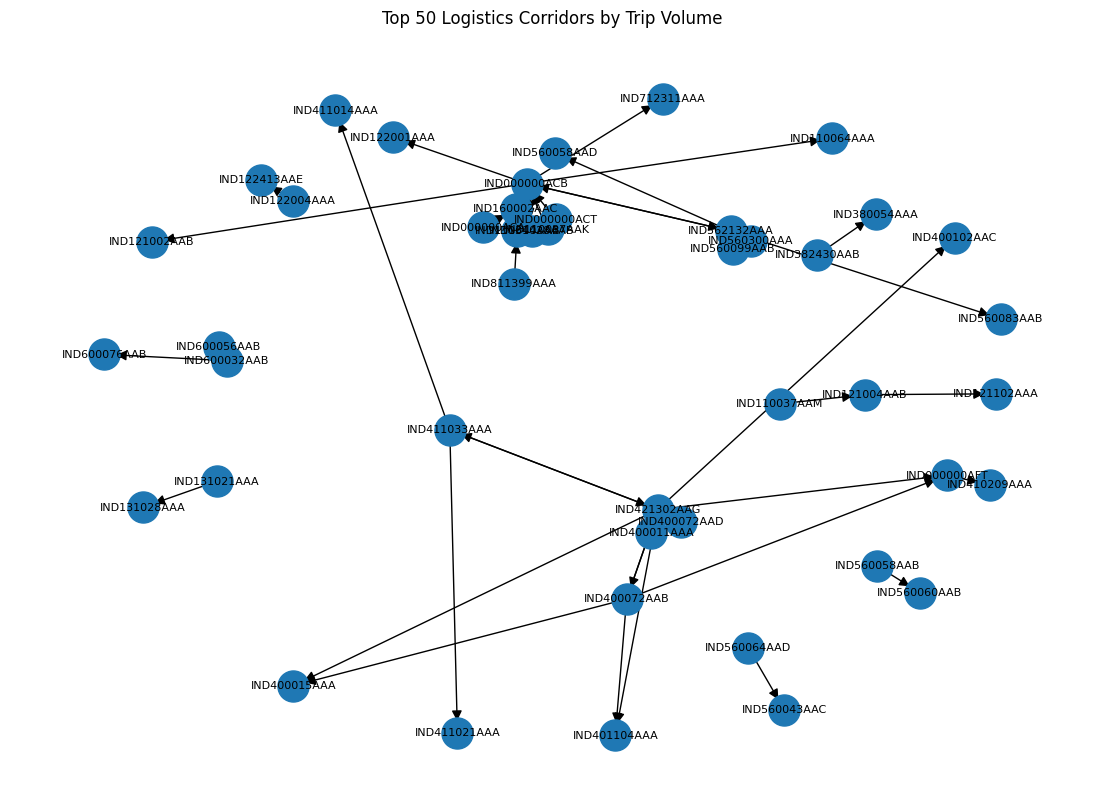

In [13]:
import matplotlib.pyplot as plt

top_edges = corridor_summary.sort_values("trips", ascending=False).head(50)

G_top = nx.DiGraph()

for _, row in top_edges.iterrows():
    G_top.add_edge(
        row["source_center"],
        row["destination_center"],
        trips=row["trips"],
        delay=row["median_delay_ratio"]
    )

plt.figure(figsize=(14, 10))

pos = nx.spring_layout(G_top, seed=42)

nx.draw_networkx_nodes(
    G_top,
    pos,
    node_size=500
)

nx.draw_networkx_edges(
    G_top,
    pos,
    arrows=True,
    arrowsize=15
)

nx.draw_networkx_labels(
    G_top,
    pos,
    font_size=8
)

plt.title("Top 50 Logistics Corridors by Trip Volume")
plt.axis("off")
plt.show()

In this phase, I converted the cleaned trip-corridor dataset into a directed logistics network. Each logistics center is represented as a node, and each source-destination corridor is represented as a directed edge. Edge attributes include trip volume, median actual time, median OSRM time, median delay ratio, delay rate, and delayed trip count.

This graph structure allows the project to move beyond normal ETA regression and analyze the logistics network as an interconnected system. High-degree and high-traffic nodes can represent important hubs, while high-delay edges can represent risky corridors.

I constructed a directed logistics network from the cleaned trip-corridor dataset. Each logistics center is represented as a node, and each source-destination movement is represented as a directed edge.

The graph contains 1,657 nodes and 2,783 edges, showing that the dataset forms a large but sparse logistics network. The graph density is 0.0010, which is expected because logistics hubs are not connected to every other hub directly.

The most connected hub is IND000000ACB with a total degree of 94 and weighted total degree of 1,991, indicating that it is both structurally important and highly active in terms of trip volume. Other important hubs include IND562132AAA, IND421302AAG, and IND160002AAC.

# Bottleneck Analysis

In [14]:
# Betweenness centrality
# This can take some time because graph has 1657 nodes

betweenness = nx.betweenness_centrality(G, normalized=True)

node_features["betweenness_centrality"] = node_features["center"].map(betweenness)

display(
    node_features
    .sort_values("betweenness_centrality", ascending=False)
    .head(10)
)

,center,in_degree,out_degree,total_degree,weighted_in_degree,weighted_out_degree,weighted_total_degree,betweenness_centrality
25,IND000000ACB,45,49,94,928,1063,1991,0.220228
12,IND562132AAA,36,35,71,665,768,1433,0.124943
64,IND501359AAE,30,27,57,405,329,734,0.092632
67,IND712311AAA,24,22,46,219,262,481,0.090659
61,IND421302AAG,29,29,58,583,821,1404,0.069625
24,IND160002AAC,32,29,61,431,370,801,0.055078
47,IND131028AAB,20,20,40,329,245,574,0.047837
110,IND781018AAB,17,15,32,90,90,180,0.044542
1,IND411033AAA,23,20,43,330,403,733,0.043254
66,IND600056AAB,18,18,36,241,300,541,0.042146


In [15]:
pagerank = nx.pagerank(G, weight="trips")

node_features["pagerank"] = node_features["center"].map(pagerank)

display(
    node_features
    .sort_values("pagerank", ascending=False)
    .head(10)
)

,center,in_degree,out_degree,total_degree,weighted_in_degree,weighted_out_degree,weighted_total_degree,betweenness_centrality,pagerank
25,IND000000ACB,45,49,94,928,1063,1991,0.220228,0.019326
12,IND562132AAA,36,35,71,665,768,1433,0.124943,0.013163
64,IND501359AAE,30,27,57,405,329,734,0.092632,0.011175
24,IND160002AAC,32,29,61,431,370,801,0.055078,0.010081
67,IND712311AAA,24,22,46,219,262,481,0.090659,0.008690
61,IND421302AAG,29,29,58,583,821,1404,0.069625,0.008233
1,IND411033AAA,23,20,43,330,403,733,0.043254,0.007394
47,IND131028AAB,20,20,40,329,245,574,0.047837,0.006446
52,IND209304AAA,16,13,29,172,220,392,0.040359,0.006092
1022,IND560099AAB,11,18,29,354,466,820,0.003475,0.005521


In [16]:
# Delay coming out of source hubs
source_delay = (
    corridor_summary
    .groupby("source_center")
    .agg(
        source_trips=("trips", "sum"),
        source_delayed_trips=("delayed_trips", "sum"),
        source_avg_delay_ratio=("median_delay_ratio", "mean")
    )
    .reset_index()
    .rename(columns={"source_center": "center"})
)

# Delay going into destination hubs
destination_delay = (
    corridor_summary
    .groupby("destination_center")
    .agg(
        destination_trips=("trips", "sum"),
        destination_delayed_trips=("delayed_trips", "sum"),
        destination_avg_delay_ratio=("median_delay_ratio", "mean")
    )
    .reset_index()
    .rename(columns={"destination_center": "center"})
)

node_features = node_features.merge(source_delay, on="center", how="left")
node_features = node_features.merge(destination_delay, on="center", how="left")

fill_cols = [
    "source_trips", "source_delayed_trips", "source_avg_delay_ratio",
    "destination_trips", "destination_delayed_trips", "destination_avg_delay_ratio"
]

node_features[fill_cols] = node_features[fill_cols].fillna(0)

node_features["total_trips_handled"] = (
    node_features["source_trips"] + node_features["destination_trips"]
)

node_features["total_delayed_trips_handled"] = (
    node_features["source_delayed_trips"] + node_features["destination_delayed_trips"]
)

node_features["hub_delay_rate"] = (
    node_features["total_delayed_trips_handled"] / node_features["total_trips_handled"]
)

node_features["hub_delay_rate"] = node_features["hub_delay_rate"].fillna(0)

display(
    node_features
    .sort_values("total_delayed_trips_handled", ascending=False)
    .head(10)
)

,center,in_degree,out_degree,total_degree,weighted_in_degree,weighted_out_degree,weighted_total_degree,betweenness_centrality,pagerank,source_trips,source_delayed_trips,source_avg_delay_ratio,destination_trips,destination_delayed_trips,destination_avg_delay_ratio,total_trips_handled,total_delayed_trips_handled,hub_delay_rate
25,IND000000ACB,45,49,94,928,1063,1991,0.220228,0.019326,1063.0,1032.0,1.995523,928.0,897.0,2.016180,1991.0,1929.0,0.968860
61,IND421302AAG,29,29,58,583,821,1404,0.069625,0.008233,821.0,821.0,2.268547,583.0,583.0,2.596171,1404.0,1404.0,1.000000
12,IND562132AAA,36,35,71,665,768,1433,0.124943,0.013163,768.0,743.0,1.813549,665.0,637.0,1.859306,1433.0,1380.0,0.963015
24,IND160002AAC,32,29,61,431,370,801,0.055078,0.010081,370.0,350.0,1.871087,431.0,418.0,3.263295,801.0,768.0,0.958801
1022,IND560099AAB,11,18,29,354,466,820,0.003475,0.005521,466.0,407.0,1.882365,354.0,327.0,2.177846,820.0,734.0,0.895122
64,IND501359AAE,30,27,57,405,329,734,0.092632,0.011175,329.0,329.0,2.105107,405.0,401.0,2.200053,734.0,730.0,0.994550
1,IND411033AAA,23,20,43,330,403,733,0.043254,0.007394,403.0,392.0,2.023778,330.0,321.0,2.302674,733.0,713.0,0.972715
47,IND131028AAB,20,20,40,329,245,574,0.047837,0.006446,245.0,244.0,2.391246,329.0,326.0,2.492844,574.0,570.0,0.993031
66,IND600056AAB,18,18,36,241,300,541,0.042146,0.005333,300.0,300.0,1.956961,241.0,241.0,4.572839,541.0,541.0,1.000000
1039,IND560300AAA,4,12,16,278,331,609,0.005632,0.003747,331.0,274.0,1.763528,278.0,264.0,2.243514,609.0,538.0,0.883415


In [17]:
from sklearn.preprocessing import MinMaxScaler

bottleneck_cols = [
    "weighted_total_degree",
    "betweenness_centrality",
    "pagerank",
    "hub_delay_rate",
    "total_delayed_trips_handled"
]

scaler = MinMaxScaler()

scaled_values = scaler.fit_transform(node_features[bottleneck_cols])

scaled_df = pd.DataFrame(
    scaled_values,
    columns=[col + "_scaled" for col in bottleneck_cols],
    index=node_features.index
)

node_features = pd.concat([node_features, scaled_df], axis=1)

node_features["bottleneck_score"] = (
    0.25 * node_features["weighted_total_degree_scaled"] +
    0.25 * node_features["betweenness_centrality_scaled"] +
    0.20 * node_features["pagerank_scaled"] +
    0.15 * node_features["hub_delay_rate_scaled"] +
    0.15 * node_features["total_delayed_trips_handled_scaled"]
)

top_bottleneck_hubs = (
    node_features
    .sort_values("bottleneck_score", ascending=False)
    .head(10)
)

display(top_bottleneck_hubs[
    [
        "center",
        "in_degree",
        "out_degree",
        "weighted_total_degree",
        "betweenness_centrality",
        "pagerank",
        "hub_delay_rate",
        "total_delayed_trips_handled",
        "bottleneck_score"
    ]
])

,center,in_degree,out_degree,weighted_total_degree,betweenness_centrality,pagerank,hub_delay_rate,total_delayed_trips_handled,bottleneck_score
25,IND000000ACB,45,49,1991,0.220228,0.019326,0.968860,1929.0,0.995329
12,IND562132AAA,36,35,1433,0.124943,0.013163,0.963015,1380.0,0.709332
61,IND421302AAG,29,29,1404,0.069625,0.008233,1.000000,1404.0,0.598983
64,IND501359AAE,30,27,734,0.092632,0.011175,0.994550,730.0,0.518328
24,IND160002AAC,32,29,801,0.055078,0.010081,0.958801,768.0,0.470315
67,IND712311AAA,24,22,481,0.090659,0.008690,1.000000,481.0,0.439883
1,IND411033AAA,23,20,733,0.043254,0.007394,0.972715,713.0,0.418183
47,IND131028AAB,20,20,574,0.047837,0.006446,0.993031,570.0,0.385475
66,IND600056AAB,18,18,541,0.042146,0.005333,1.000000,541.0,0.362073
1022,IND560099AAB,11,18,820,0.003475,0.005521,0.895122,734.0,0.354456


In [18]:
# Add delay contribution percentage
corridor_summary["delay_contribution_pct"] = (
    corridor_summary["delayed_trips"] / corridor_summary["delayed_trips"].sum() * 100
)

# Reliable corridors only
min_trips = 5

reliable_corridors = corridor_summary[
    corridor_summary["trips"] >= min_trips
].copy()

top_delayed_corridors = (
    reliable_corridors
    .sort_values(
        ["delay_rate", "median_delay_ratio", "delayed_trips"],
        ascending=[False, False, False]
    )
    .head(10)
)

display(top_delayed_corridors[
    [
        "corridor",
        "trips",
        "median_actual_time",
        "median_osrm_time",
        "median_delay_ratio",
        "delay_rate",
        "delayed_trips",
        "delay_contribution_pct"
    ]
])

,corridor,trips,median_actual_time,median_osrm_time,median_delay_ratio,delay_rate,delayed_trips,delay_contribution_pct
455,IND208012AAA -> IND209304AAA,13,666.0,15.0,41.500000,1.0,13,0.051990
488,IND212402AAA -> IND211002AAB,13,1049.0,36.0,29.138889,1.0,13,0.051990
2600,IND792121AAB -> IND786181AAC,11,896.0,29.0,28.903226,1.0,11,0.043991
1139,IND416606AAA -> IND416510AAA,10,1207.0,45.5,26.880918,1.0,10,0.039992
2616,IND802212AAA -> IND821115AAB,7,962.0,41.0,23.738095,1.0,7,0.027994
1213,IND425405AAA -> IND424006AAA,14,1035.0,48.0,21.232476,1.0,14,0.055989
476,IND209801AAA -> IND209304AAA,5,685.0,33.0,20.757576,1.0,5,0.019996
456,IND208017AAA -> IND209304AAA,6,242.0,12.0,16.947917,1.0,6,0.023995
2431,IND743270AAA -> IND712311AAA,5,1136.0,73.0,15.351351,1.0,5,0.019996
2349,IND722151AAA -> IND723130AAA,8,1054.0,70.0,15.060049,1.0,8,0.031994


In [19]:
top_delay_contributors = (
    reliable_corridors
    .sort_values(
        ["delayed_trips", "delay_contribution_pct", "median_delay_ratio"],
        ascending=[False, False, False]
    )
    .head(10)
)

display(top_delay_contributors[
    [
        "corridor",
        "trips",
        "median_delay_ratio",
        "delay_rate",
        "delayed_trips",
        "delay_contribution_pct"
    ]
])

,corridor,trips,median_delay_ratio,delay_rate,delayed_trips,delay_contribution_pct
1775,IND562132AAA -> IND560300AAA,151,1.729167,0.966887,146,0.583883
1774,IND562132AAA -> IND560099AAB,127,1.666667,0.992126,126,0.503899
1719,IND560099AAB -> IND560300AAA,121,1.833333,0.925620,112,0.447910
1080,IND411033AAA -> IND421302AAG,107,1.990476,1.000000,107,0.427914
1735,IND560300AAA -> IND562132AAA,108,1.830000,0.981481,106,0.423915
1152,IND421302AAG -> IND400072AAB,105,2.545455,1.000000,105,0.419916
1010,IND400072AAD -> IND421302AAG,99,2.727273,1.000000,99,0.395921
38,IND000000ACB -> IND131028AAB,92,2.074076,1.000000,92,0.367926
1720,IND560099AAB -> IND562132AAA,102,1.518519,0.892157,91,0.363927
211,IND131028AAB -> IND000000ACB,86,1.906426,0.988372,85,0.339932


In [20]:
import os

os.makedirs("outputs/tables", exist_ok=True)

node_features.to_csv("data/processed/node_features_bottleneck.csv", index=False)
top_bottleneck_hubs.to_csv("outputs/tables/top_bottleneck_hubs.csv", index=False)
top_delayed_corridors.to_csv("outputs/tables/top_delayed_corridors.csv", index=False)
top_delay_contributors.to_csv("outputs/tables/top_delay_contributors.csv", index=False)

print("Saved Phase 3 bottleneck analysis outputs.")

Saved Phase 3 bottleneck analysis outputs.


From the bottleneck ranking, I can see that IND000000ACB is the most critical hub because it has high traffic volume, high connectivity, and high graph importance. This suggests that delays at this hub may affect many downstream corridors.

Operationally, this means the company should investigate capacity, dispatch scheduling, dwell time, and route load at this hub before focusing only on low-volume delayed corridors.

From the bottleneck analysis, IND000000ACB emerges as the most critical hub in the logistics network. It has the highest connectivity, highest weighted traffic volume, highest betweenness centrality, highest PageRank, and handles 1,929 delayed trip movements. This suggests that IND000000ACB is not only a busy hub but also structurally important in the network.

The corridor analysis shows two different delay patterns. Some corridors have extremely high median delay ratios, such as IND208012AAA -> IND209304AAA, but they have relatively low trip volume. These routes may represent severe operational anomalies. On the other hand, corridors such as IND562132AAA -> IND560300AAA and IND562132AAA -> IND560099AAB contribute the highest number of delayed trips. These high-volume delayed corridors should be prioritized first for operational improvement because fixing them can reduce more total delayed shipments.